# Explore Data

In [7]:
import xarray as xr
import yaml

from pathlib import Path
from matplotlib import pyplot as plt

In [8]:
# Load the initial dataset before adding wet bulb temperature. 
ds = xr.open_dataset("../ifs_2t_dp_msl.nc")
ds

<xarray.Dataset> Size: 112MB
Dimensions:            (step: 9, latitude: 721, longitude: 1440)
Coordinates:
  * step               (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days ...
    valid_time         (step) datetime64[ns] 72B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    time               datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables:
    t2m                (step, latitude, longitude) float32 37MB ...
    d2m                (step, latitude, longitude) float32 37MB ...
    msl                (step, latitude, longitude) float32 37MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-01T21:08 GRIB to CDM+CF via cfgrib-0.9.1...

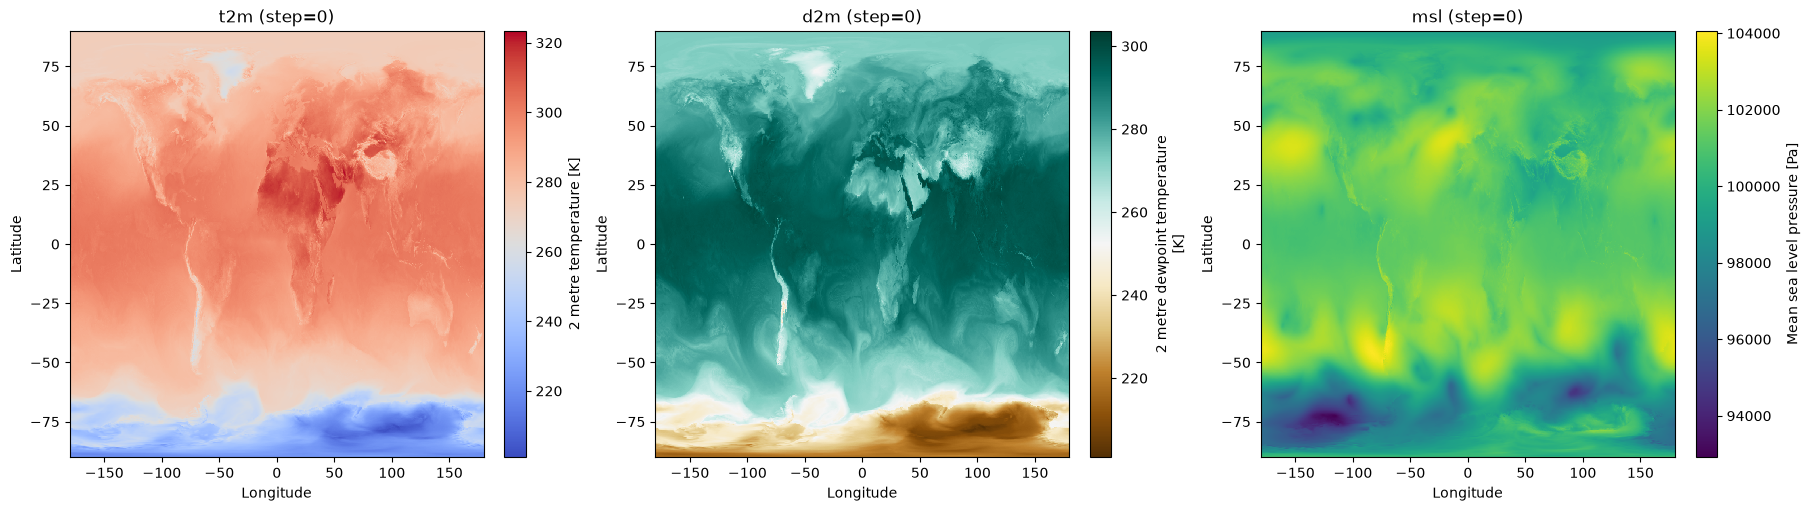

In [12]:
# Plot t2m, d2m and sp for the first available time/step indices
indexers = {}
if "time" in ds.dims:
    indexers["time"] = 0
if "step" in ds.dims:
    indexers["step"] = 0

first_slice = ds.isel(**indexers)

label_parts = [f"{k}=0" for k in ("time", "step") if k in indexers]
label = ", ".join(label_parts) if label_parts else "first slice"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

first_slice["t2m"].plot(ax=axes[0], cmap="coolwarm")
axes[0].set_title(f"t2m ({label})")

first_slice["d2m"].plot(ax=axes[1], cmap="BrBG")
axes[1].set_title(f"d2m ({label})")

first_slice["msl"].plot(ax=axes[2], cmap="viridis")
axes[2].set_title(f"msl ({label})")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.show()

In [13]:
# Load the dataset with wet bulb temperature added
ds = xr.open_dataset("../ifs_2t_dp_msl_tw.nc")
ds

<xarray.Dataset> Size: 187MB
Dimensions:            (step: 9, latitude: 721, longitude: 1440)
Coordinates:
  * step               (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days ...
    valid_time         (step) datetime64[ns] 72B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    time               datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    meanSea            float64 8B ...
Data variables:
    t2m                (step, latitude, longitude) float32 37MB ...
    d2m                (step, latitude, longitude) float32 37MB ...
    msl                (step, latitude, longitude) float32 37MB ...
    tw                 (step, latitude, longitude) float64 75MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-01T21:08 GRIB to CDM+CF via cfgrib-0.9.1...

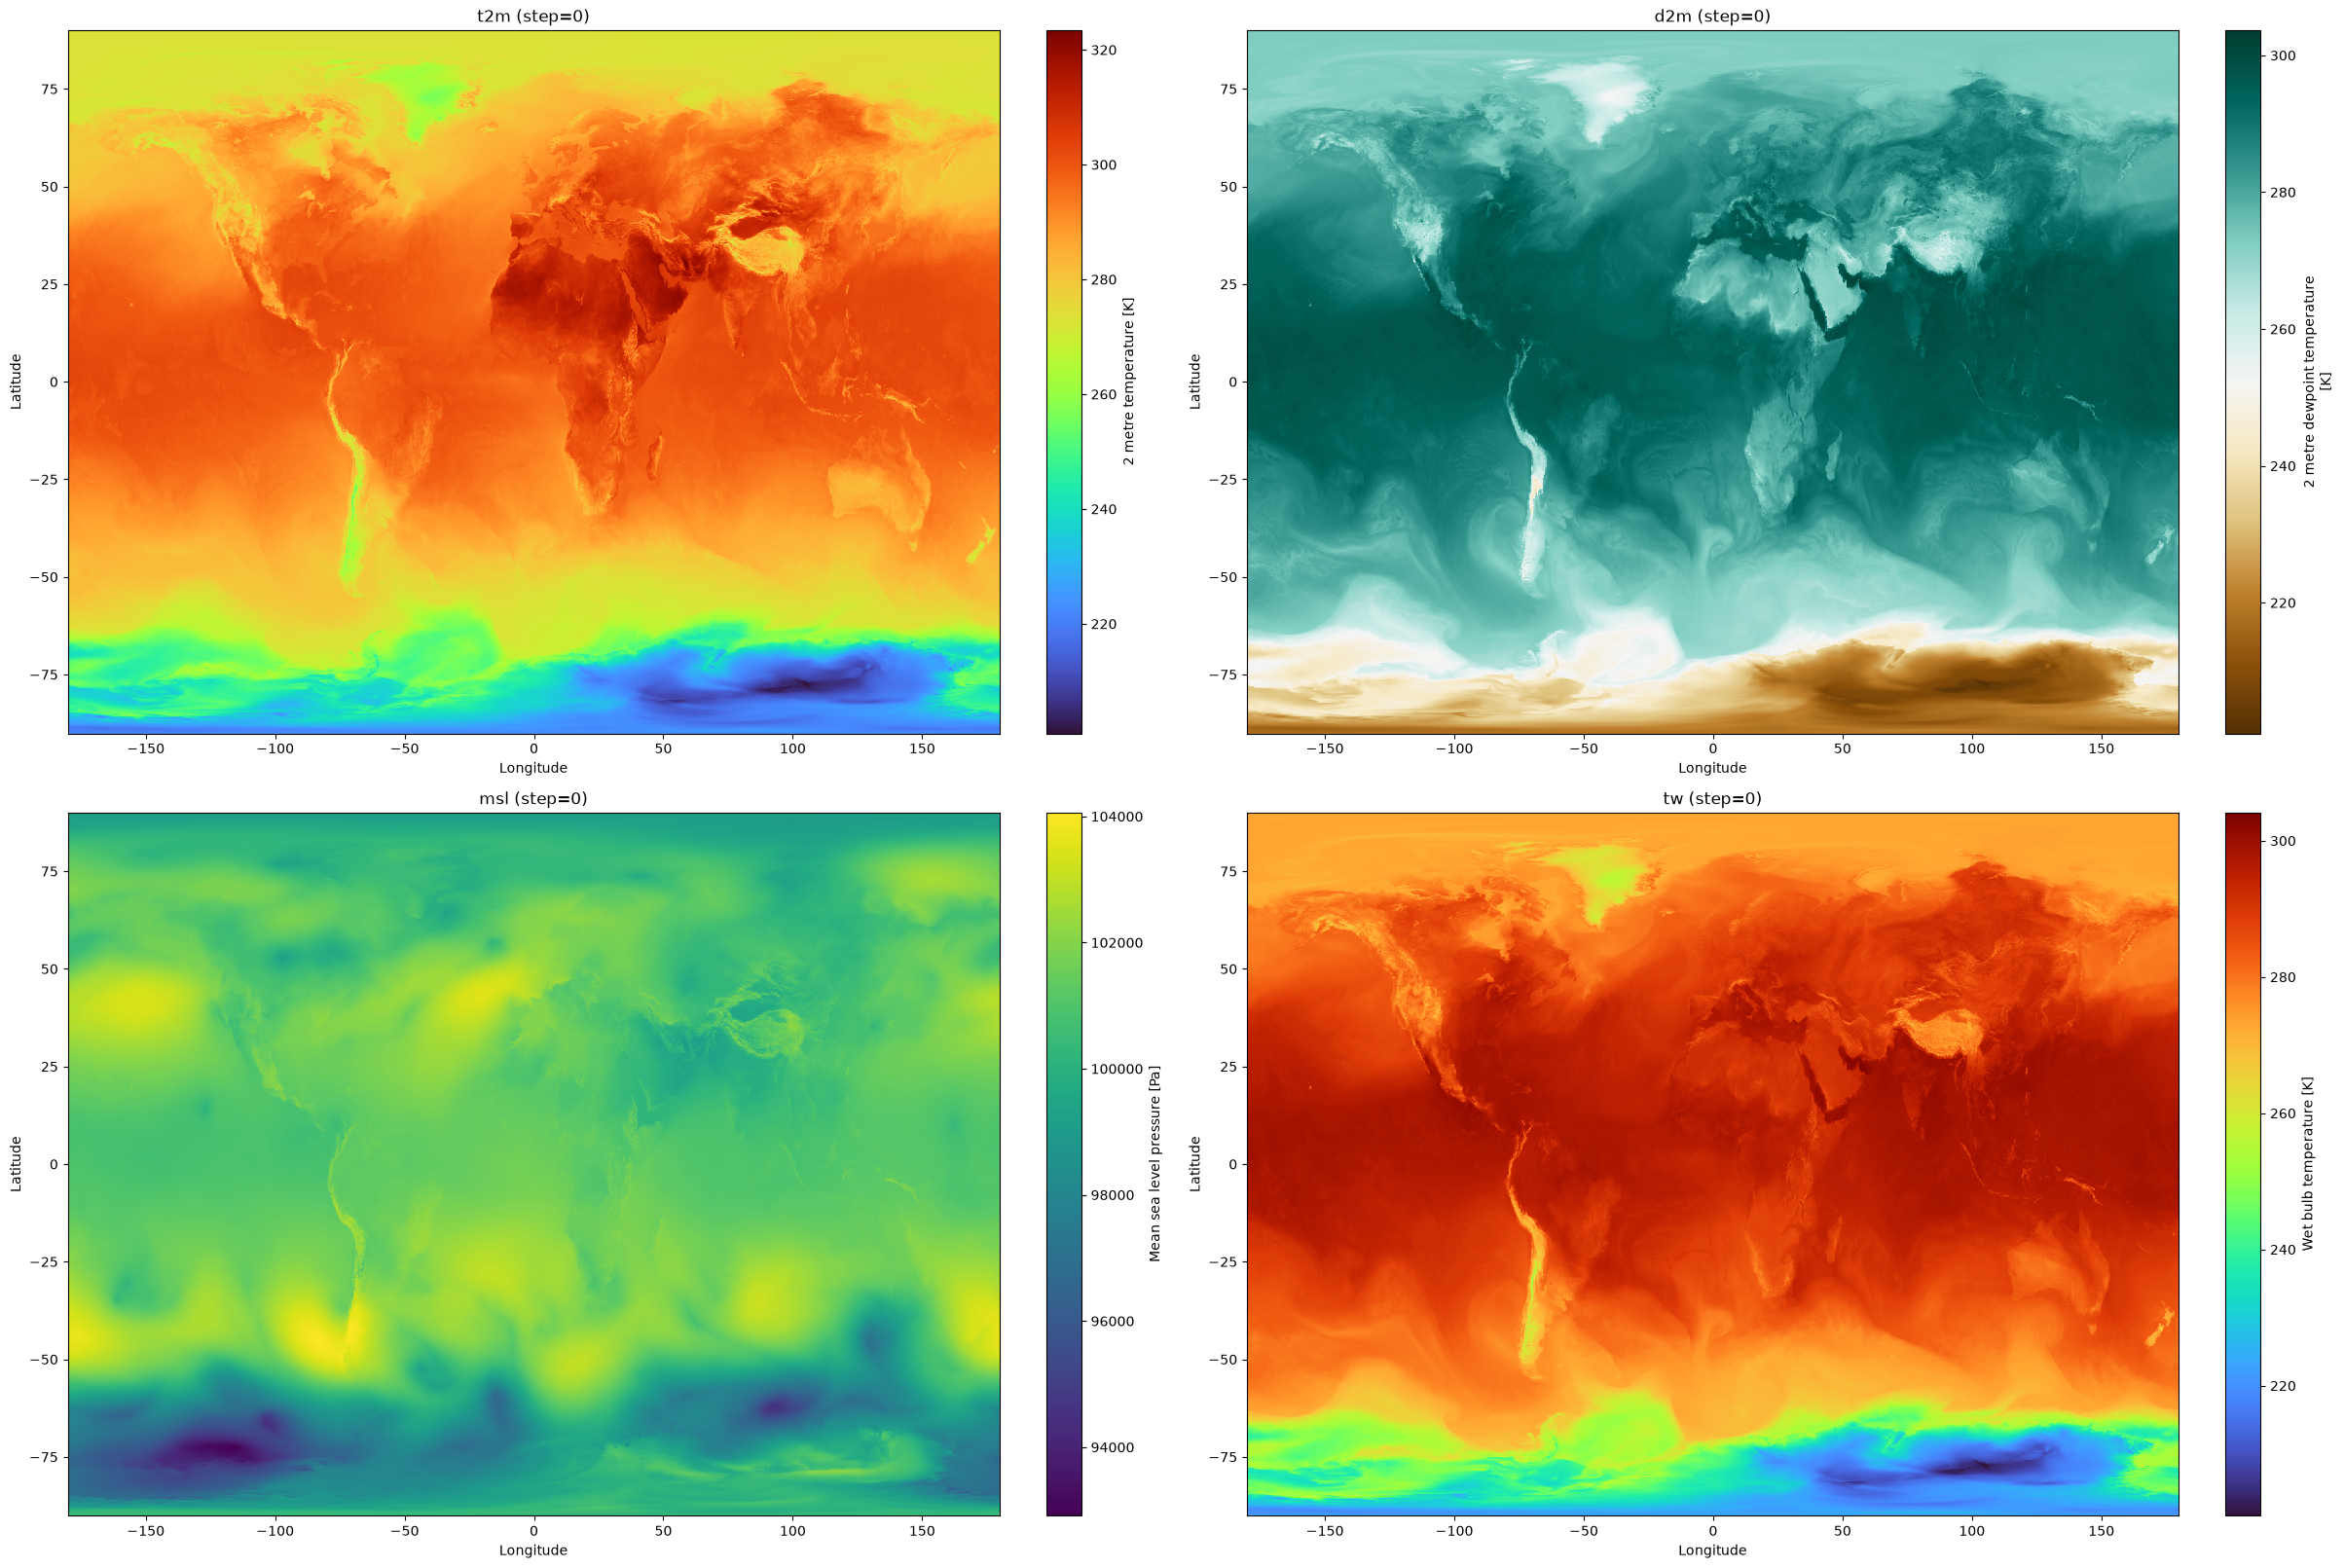

In [30]:
# Plot t2m, d2m, msl, and tw for the first available time/step indices
indexers = {}
if "time" in ds.dims:
    indexers["time"] = 0
if "step" in ds.dims:
    indexers["step"] = 0

first_slice = ds.isel(**indexers)

label_parts = [f"{k}=0" for k in ("time", "step") if k in indexers]
label = ", ".join(label_parts) if label_parts else "first slice"

fig, axes = plt.subplots(2, 2, figsize=(24, 16), constrained_layout=True)
axes = axes.flatten()

first_slice["t2m"].plot(ax=axes[0], cmap="turbo")
axes[0].set_title(f"t2m ({label})")

first_slice["d2m"].plot(ax=axes[1], cmap="BrBG")
axes[1].set_title(f"d2m ({label})")

first_slice["msl"].plot(ax=axes[2], cmap="viridis")
axes[2].set_title(f"msl ({label})")

first_slice["tw"].plot(ax=axes[3], cmap="turbo")
axes[3].set_title(f"tw ({label})")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.show()

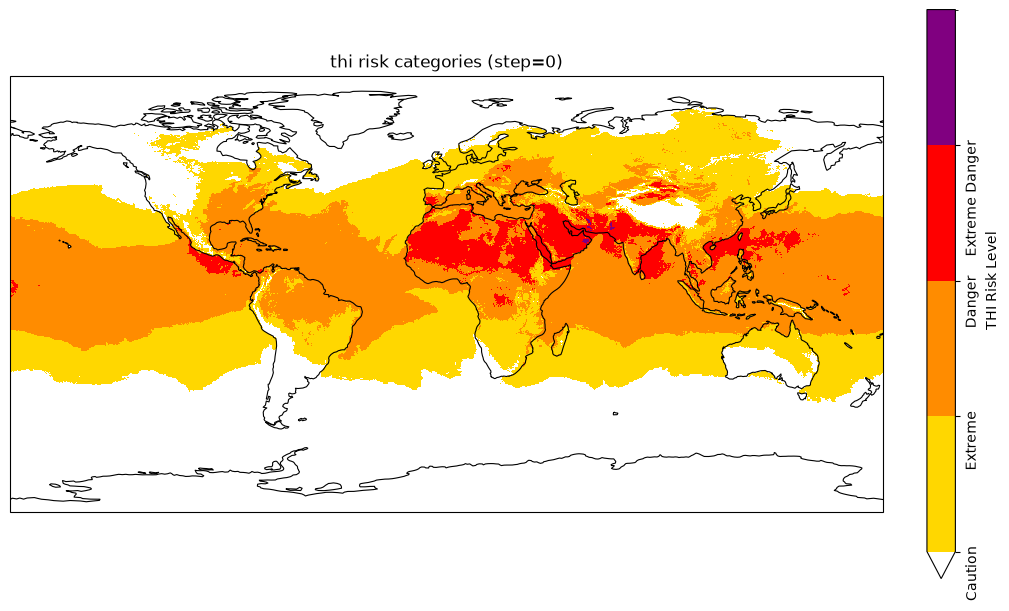

In [ ]:
# Plot thi from ifs_thi.nc for the first available time/step indices
import numpy as np
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm

ds_thi = xr.open_dataset("../ifs_thi.nc")

indexers = {}
if "time" in ds_thi.dims:
    indexers["time"] = 0
if "step" in ds_thi.dims:
    indexers["step"] = 0

thi_first = ds_thi["thi"].isel(**indexers)

label_parts = [f"{k}=0" for k in ("time", "step") if k in indexers]
label = ", ".join(label_parts) if label_parts else "first slice"

# Custom THI categories
bounds = [20, 21, 24, 25, 27, 1e6]
cmap = ListedColormap(["#22FF00","#FFD700", "#FF8C00", "#FF0000", "#EF00EF"])
cmap.set_under((1, 1, 1, 0))
norm = BoundaryNorm(bounds, cmap.N)

# Tick labels at the start of each color section
tick_locs = bounds[:-1]
tick_labels = ["Few", "Some", "Half", "Many", "All"]

fig, ax = plt.subplots(
    figsize=(10, 6),
    constrained_layout=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
)
mappable = thi_first.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={"ticks": tick_locs, "label": "THI Risk Level"},
)
mappable.colorbar.set_ticklabels(tick_labels)
mappable.colorbar.ax.tick_params(labelrotation=90)
ax.coastlines(linewidth=0.8)
ax.set_title(f"thi risk categories ({label})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()